# Procesamiento de Imágenes con la Transformada Rápida de Fourier (FFT)

**Universidad Centroamericana "José Simeón Cañas"**  
Facultad de Ingeniería y Arquitectura — Departamento de Matemática  
Análisis Numérico · Ciclo 01-2026  

---

## Descripción general

En este notebook se explora la aplicación de la **Transformada Discreta de Fourier (DFT)** 
en dos dimensiones para el procesamiento digital de imágenes. 
Específicamente, se estudia cómo el **filtrado en el dominio de la frecuencia** permite 
eliminar ruido de una imagen utilizando un filtro gaussiano paso-bajo.

El flujo de trabajo seguido es el siguiente:

1. Carga y preprocesamiento de la imagen.
2. Adición de ruido gaussiano sintético.
3. Cálculo de la FFT 2D.
4. Construcción y aplicación de un filtro gaussiano en el dominio frecuencial.
5. Reconstrucción mediante la IFFT 2D.
6. Análisis comparativo de resultados.


---
## 1. Marco Teórico

### 1.1 Transformada Discreta de Fourier en 2D

Para una imagen discreta $f[m, n]$ de tamaño $M \times N$, la **DFT 2D** se define como:

$$
F[u, v] = \sum_{m=0}^{M-1} \sum_{n=0}^{N-1} f[m,n]\, e^{-j2\pi\left(\frac{um}{M} + \frac{vn}{N}\right)}
$$

donde $u \in \{0,\dots,M-1\}$ y $v \in \{0,\dots,N-1\}$ son las frecuencias espaciales discretas.
Cada coeficiente $F[u,v]$ es un número complejo cuya **magnitud** representa la energía en esa frecuencia
y cuya **fase** codifica la posición espacial de esa componente.

Para imágenes **RGB**, la DFT se aplica de forma independiente a cada canal $c \in \{R, G, B\}$:

$$
F_c[u, v] = \sum_{m=0}^{M-1} \sum_{n=0}^{N-1} f_c[m,n]\, e^{-j2\pi\left(\frac{um}{M} + \frac{vn}{N}\right)}
$$

### 1.2 Transformada Inversa (IDFT 2D)

La imagen original se recupera mediante la transformada inversa:

$$
f[m, n] = \frac{1}{MN} \sum_{u=0}^{M-1} \sum_{v=0}^{N-1} F[u,v]\, e^{j2\pi\left(\frac{um}{M} + \frac{vn}{N}\right)}
$$

### 1.3 Desplazamiento del espectro (`fftshift`)

Por convención, la FFT coloca las frecuencias bajas en las esquinas de la matriz.
La operación **fftshift** reordena el espectro para centrar las frecuencias bajas:

$$
F_{\text{shift}}[u, v] = F\left[\left(u + \frac{M}{2}\right) \bmod M,\; \left(v + \frac{N}{2}\right) \bmod N\right]
$$

### 1.4 Filtro Gaussiano Paso-Bajo

Un filtro paso-bajo atenúa las frecuencias altas (bordes, ruido) y preserva las bajas (estructura global).
El filtro gaussiano en el dominio de la frecuencia se define como:

$$
H[u, v] = e^{-\dfrac{(u - u_0)^2 + (v - v_0)^2}{2\sigma^2}}
$$

donde $(u_0, v_0)$ es el centro del espectro y $\sigma$ controla el **ancho de banda**.
El espectro filtrado se obtiene mediante multiplicación punto a punto:

$$
G[u, v] = F_{\text{shift}}[u, v] \cdot H[u, v]
$$


---
## 2. Configuración del Entorno

Se importan las bibliotecas necesarias:
- **NumPy**: operaciones numéricas y módulo `fft`.
- **Matplotlib**: visualización de imágenes y espectros.
- **PIL (Pillow)**: carga y conversión de imágenes.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print("Todo funciona")

Todo funciona


---
## 3. Carga y Preprocesamiento de la Imagen

La imagen se carga en modo **RGB** para preservar la información de color en los tres canales $(R, G, B)$.

Para optimizar el cómputo se limita el lado máximo a $512$ píxeles, pero manteniendo la **proporción original** de la imagen mediante regla de tres:

$$
\text{Si } W > H:\quad W' = 512,\quad H' = \left\lfloor 512 \times \frac{H}{W} \right\rfloor
$$
$$
\text{Si } H \geq W:\quad H' = 512,\quad W' = \left\lfloor 512 \times \frac{W}{H} \right\rfloor
$$

Así se evita la deformación de imágenes rectangulares y se trabaja con dimensiones uniformes.


Tamaño original : 425 x 437 px
Tamaño redimensionado: 497 x 512 px  |  canales: 3


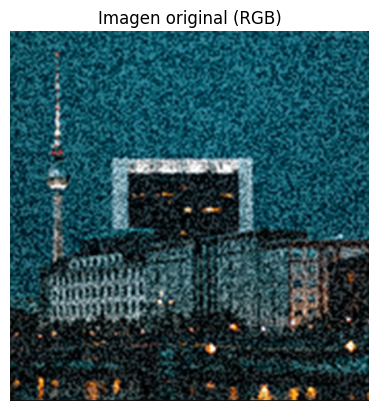

In [111]:
# ── Cargar imagen en color (RGB) ─────────────────────────────────────────
img_pil = Image.open("imagenes/imagenR4.png").convert("RGB")

# ── Redimensionar manteniendo proporción ──────────────────────────────────
MAX_SIZE = 512
W_orig, H_orig = img_pil.size   # PIL usa (ancho, alto)

if W_orig >= H_orig:
    W_new = MAX_SIZE
    H_new = int(MAX_SIZE * H_orig / W_orig)
else:
    H_new = MAX_SIZE
    W_new = int(MAX_SIZE * W_orig / H_orig)

img_pil = img_pil.resize((W_new, H_new), Image.LANCZOS)
img = np.array(img_pil)          # shape: (H_new, W_new, 3)  dtype: uint8

print(f"Tamaño original : {W_orig} x {H_orig} px")
print(f"Tamaño redimensionado: {img.shape[1]} x {img.shape[0]} px  |  canales: {img.shape[2]}")

plt.imshow(img)
plt.title("Imagen original (RGB)")
plt.axis('off')
plt.show()


---
## 4. Selección del Modo de Procesamiento

El flujo de trabajo se bifurca según la condición de la imagen de entrada:

| Opción | Descripción | Resultado |
|--------|-------------|----------|
| **a) Añadir ruido** | La imagen está limpia; se agrega ruido gaussiano sintético | Se muestra imagen original vs. reconstrucción filtrada |
| **b) Ya tiene ruido** | La imagen subida ya contiene ruido real | Se muestra imagen ruidosa vs. imagen depurada |

Asigna el valor `'a'` o `'b'` a la variable `MODO` en la celda siguiente.


In [113]:
# ── CONFIGURACIÓN DE MODO ────────────────────────────────────────────────
#   'a'  →  la imagen está limpia; se añadirá ruido gaussiano sintético
#   'b'  →  la imagen ya contiene ruido; se omite la adición de ruido
MODO = 'b'   # <── cambia a 'b' si tu imagen ya tiene ruido

assert MODO in ('a', 'b'), "MODO debe ser 'a' o 'b'"
print(f"Modo seleccionado: {'(a) Añadir ruido' if MODO == 'a' else '(b) Imagen ya con ruido'}")


Modo seleccionado: (b) Imagen ya con ruido


---
## 5. (Opción a) Adición de Ruido Gaussiano

> **Esta sección solo se ejecuta si `MODO = 'a'`.**

Se añade **ruido blanco gaussiano** independiente a cada canal RGB. El ruido $\eta_c[m,n]$ en el canal $c$ sigue:

$$
\eta_c[m,n] \sim \mathcal{N}(0,\, \sigma_\eta^2) \quad c \in \{R, G, B\}, \quad \sigma_\eta = 40
$$

La imagen degradada resulta: $f_{\text{ruido}}[m,n,c] = \text{clip}\,(f[m,n,c] + \eta_c[m,n],\, 0,\, 255)$

El recorte (`clip`) garantiza que los valores permanezcan en el rango válido de píxeles $[0, 255]$.


In [114]:
if MODO == 'a':
    # ── Ruido gaussiano sobre cada canal RGB ──────────────────────────────
    sigma_ruido = 50                            # intensidad del ruido
    noise = np.random.normal(0, sigma_ruido, img.shape)
    img_ruidosa = np.clip(img.astype(float) + noise, 0, 255)

    plt.imshow(img_ruidosa.astype(np.uint8))
    plt.title(f"Imagen con ruido gaussiano ($\\sigma_{{\\eta}}={sigma_ruido}$)")
    plt.axis('off')
    plt.show()
    print(f"Ruido añadido  |  shape: {img_ruidosa.shape}  |  dtype: float64")
else:
    # ── En modo b la imagen cargada ya es la imagen ruidosa ───────────────
    img_ruidosa = img.astype(float)
    print("Modo b: se omite adición de ruido. Se usará la imagen cargada directamente.")


Modo b: se omite adición de ruido. Se usará la imagen cargada directamente.


---
## 6. Cálculo de la FFT 2D (por canal RGB)

Se aplica `numpy.fft.fft2` de forma independiente a cada canal $c \in \{R, G, B\}$, implementando el algoritmo **Cooley-Tukey** con complejidad $\mathcal{O}(MN \log MN)$.
Luego se aplica `fftshift` para centrar las frecuencias bajas $(u=0,v=0)$ en el centro de la matriz.

El resultado es un arreglo complejo de shape $(H, W, 3)$ donde cada canal tiene su propio espectro.


In [115]:
rows, cols, _ = img_ruidosa.shape
crow, ccol    = rows // 2, cols // 2
Y, X          = np.ogrid[:rows, :cols]

# FFT 2D independiente por canal
F_canales       = np.stack([np.fft.fft2(img_ruidosa[:, :, c]) for c in range(3)], axis=-1)
F_shift_canales = np.stack([np.fft.fftshift(F_canales[:, :, c]) for c in range(3)], axis=-1)

print("FFT lista  |  shape espectro:", F_shift_canales.shape)


FFT lista  |  shape espectro: (512, 497, 3)


---
## 7. Visualización del Espectro de Frecuencias

El espectro se visualiza usando la **magnitud en escala logarítmica** para comprimir el rango dinámico:

$$
\text{Espectro}_c[u,v] = \log\bigl(|F_{\text{shift},c}[u,v]| + 1\bigr)
$$

Se muestran los tres canales RGB de forma independiente.


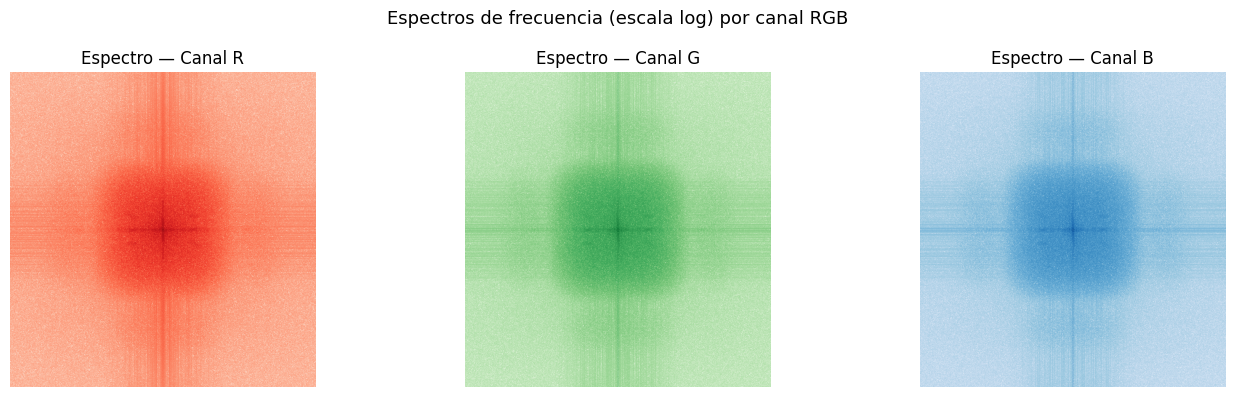

In [116]:
nombres_canales = ['Canal R', 'Canal G', 'Canal B']
cmaps           = ['Reds', 'Greens', 'Blues']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for c in range(3):
    magnitude = np.log(np.abs(F_shift_canales[:, :, c]) + 1)
    axes[c].imshow(magnitude, cmap=cmaps[c])
    axes[c].set_title(f"Espectro — {nombres_canales[c]}")
    axes[c].axis('off')
plt.suptitle("Espectros de frecuencia (escala log) por canal RGB", fontsize=13)
plt.tight_layout()
plt.show()


---
## 8. Construcción del Filtro Gaussiano Paso-Bajo

Se construye la máscara $H[u,v]$ centrada en $(u_0, v_0) = (M/2, N/2)$:

$$
H[u, v] = \exp\!\left(-\frac{(u - u_0)^2 + (v - v_0)^2}{2\sigma^2}\right)
$$

El **mismo filtro** se aplica a los tres canales, ya que la geometría frecuencial
es idéntica para todos ellos (depende únicamente de la resolución espacial).


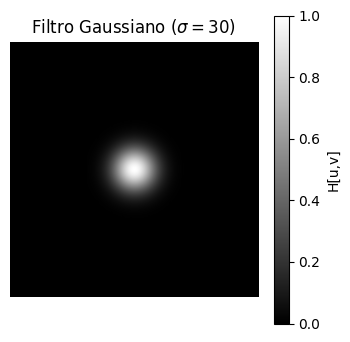

In [117]:
sigma = 30   # ancho de banda del filtro

gaussian_filter = np.exp(-((X - ccol)**2 + (Y - crow)**2) / (2 * sigma**2))

plt.figure(figsize=(4, 4))
plt.imshow(gaussian_filter, cmap='gray')
plt.title(f"Filtro Gaussiano ($\\sigma={sigma}$)")
plt.colorbar(label='H[u,v]')
plt.axis('off')
plt.show()


---
## 9. Aplicación del Filtro y Reconstrucción (IFFT 2D)

Se aplica el filtro a cada canal (Teorema de Convolución) y se reconstruye la imagen mediante la IFFT 2D:

$$
G_c[u,v] = F_{\text{shift},c}[u,v] \cdot H[u,v]
\qquad
\hat{f}_c[m,n] = \mathcal{F}^{-1}\{G_c[u,v]\}
$$

Se toma la **magnitud** del resultado complejo y se reensamblan los canales en un tensor RGB.


In [118]:
canales_filtrados = []
for c in range(3):
    G        = F_shift_canales[:, :, c] * gaussian_filter  # filtrar en frecuencia
    canal_r  = np.abs(np.fft.ifft2(np.fft.ifftshift(G)))   # regresar al dominio espacial
    canales_filtrados.append(canal_r)

# Rearmar imagen RGB y recortar valores al rango [0, 255]
img_filtrada = np.stack(canales_filtrados, axis=-1)
img_filtrada = np.clip(img_filtrada, 0, 255).astype(np.uint8)

print("Imagen reconstruida  |  shape:", img_filtrada.shape)


Imagen reconstruida  |  shape: (512, 497, 3)


---
## 10. Resultados y Comparación Final

La visualización se adapta al modo elegido:

- **Modo a** *(imagen limpia + ruido sintético)*: muestra **Original → Con ruido → Filtrada**.
- **Modo b** *(imagen ya ruidosa)*: muestra **Imagen subida (ruidosa) → Imagen depurada**.


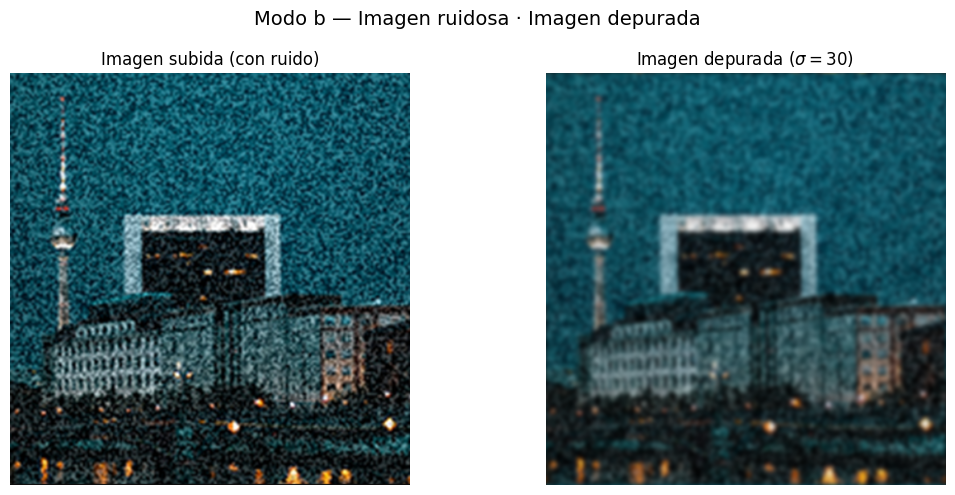

In [119]:
if MODO == 'a':
    # ── Modo a: tres paneles ───────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(img)
    axes[0].set_title("Original (limpia)", fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(img_ruidosa.astype(np.uint8))
    axes[1].set_title(f"Con ruido gaussiano ($\\sigma_{{\\eta}}={sigma_ruido}$)", fontsize=12)
    axes[1].axis('off')

    axes[2].imshow(img_filtrada)
    axes[2].set_title(f"Filtrada ($\\sigma={sigma}$)", fontsize=12)
    axes[2].axis('off')

    plt.suptitle("Modo a — Original · Con ruido · Filtrada", fontsize=14)

else:
    # ── Modo b: dos paneles ────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))

    axes[0].imshow(img)   # img es la imagen subida (ya ruidosa en modo b)
    axes[0].set_title("Imagen subida (con ruido)", fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(img_filtrada)
    axes[1].set_title(f"Imagen depurada ($\\sigma={sigma}$)", fontsize=12)
    axes[1].axis('off')

    plt.suptitle("Modo b — Imagen ruidosa · Imagen depurada", fontsize=14)

plt.tight_layout()
plt.show()


---
## 11. Experimento: Efecto del Parámetro $\sigma$

Se varía $\sigma \in \{10, 30, 60, 100\}$ para analizar el compromiso entre **eliminación de ruido** y **preservación de detalle**:

- $\sigma$ pequeño → filtro estrecho → alta suavización (posible pérdida de bordes).
- $\sigma$ grande → filtro ancho → conserva más detalle pero elimina menos ruido.


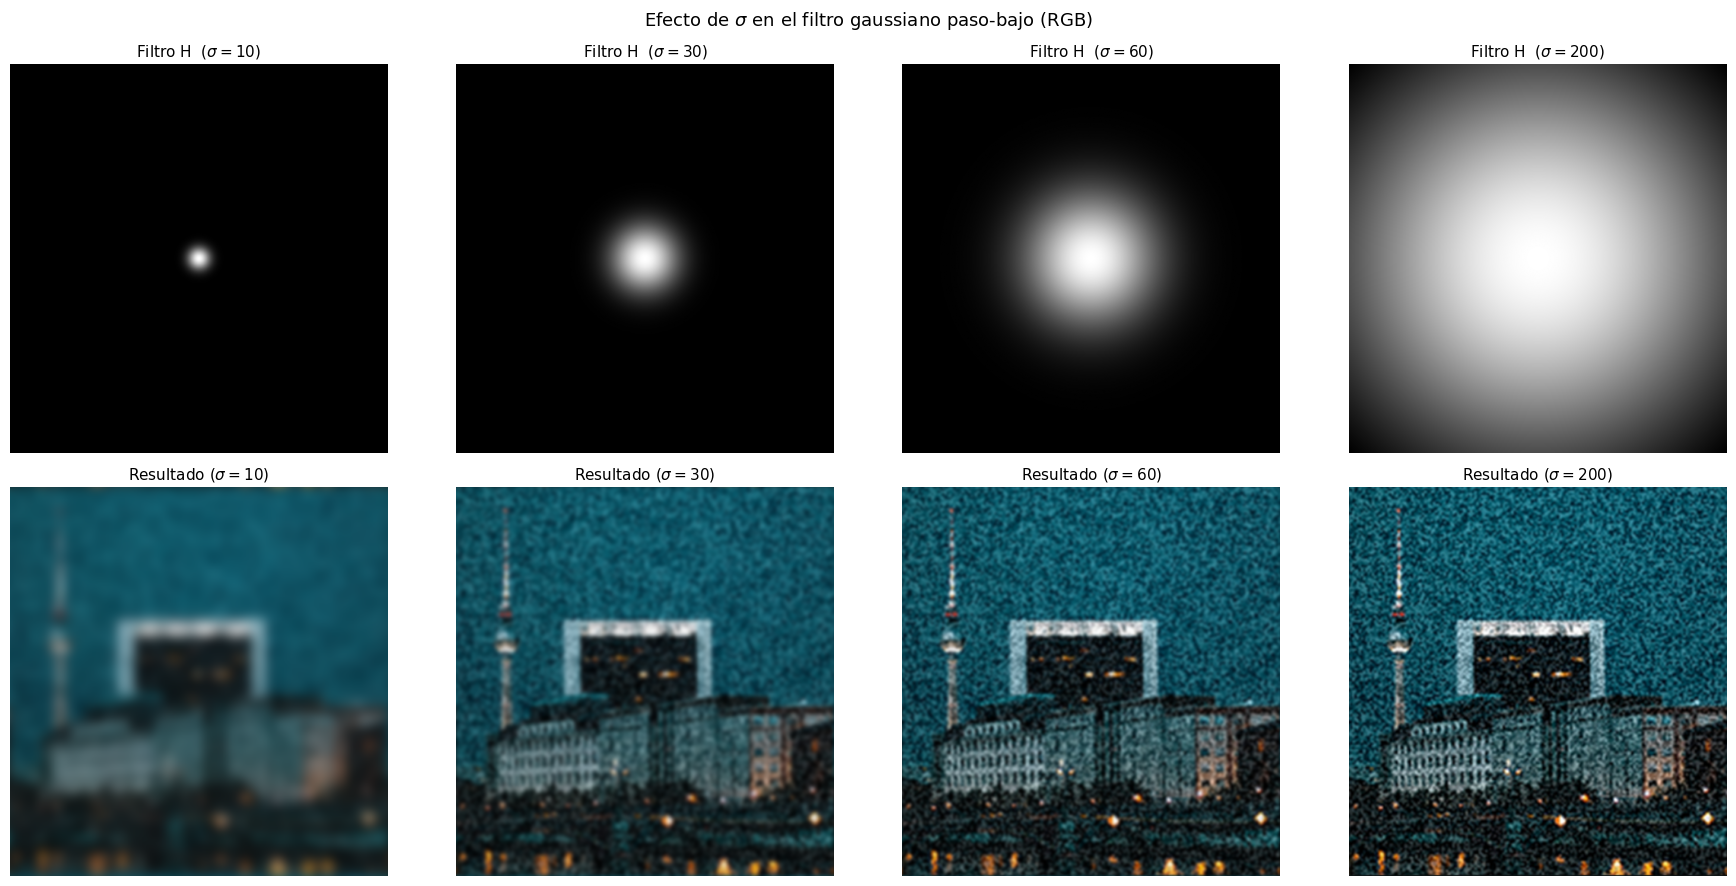

In [120]:
sigmas = [10, 30, 60, 200]

# ── Imagen base para el experimento ──────────────────────────────────────
if MODO == 'a':
    img_exp = img_ruidosa   # ya tiene ruido sintético
else:
    img_exp = img.astype(float)  # en modo b la imagen subida ya es ruidosa

# FFT por canal para el experimento
F_exp       = np.stack([np.fft.fft2(img_exp[:, :, c]) for c in range(3)], axis=-1)
F_shift_exp = np.stack([np.fft.fftshift(F_exp[:, :, c]) for c in range(3)], axis=-1)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for i, sig in enumerate(sigmas):
    H = np.exp(-((X - ccol)**2 + (Y - crow)**2) / (2 * sig**2))

    # Reconstruir imagen RGB
    canales_rec = []
    for c in range(3):
        G = F_shift_exp[:, :, c] * H
        canales_rec.append(np.abs(np.fft.ifft2(np.fft.ifftshift(G))))
    img_rec = np.clip(np.stack(canales_rec, axis=-1), 0, 255).astype(np.uint8)

    # Fila 0: filtro gaussiano
    axes[0, i].imshow(H, cmap='gray')
    axes[0, i].set_title(f'Filtro H  ($\\sigma={sig}$)', fontsize=11)
    axes[0, i].axis('off')

    # Fila 1: imagen reconstruida en color
    axes[1, i].imshow(img_rec)
    axes[1, i].set_title(f'Resultado ($\\sigma={sig}$)', fontsize=11)
    axes[1, i].axis('off')

plt.suptitle(r'Efecto de $\sigma$ en el filtro gaussiano paso-bajo (RGB)', fontsize=13)
plt.tight_layout()
plt.show()


---
## 12. Conclusiones

1. **La FFT 2D permite filtrar eficientemente en el dominio de la frecuencia.** 
Gracias al algoritmo Cooley-Tukey, la complejidad se reduce de $O(M^2N^2)$ a $O(MN\log MN)$, 
haciendo el proceso viable incluso para imágenes de alta resolución.

2. **El filtro gaussiano paso-bajo atenúa el ruido blanco preservando la estructura global.** 
El ruido, al distribuirse uniformemente en todas las frecuencias, es suprimido 
por el decaimiento gaussiano que penaliza las frecuencias altas.

3. **El parámetro $\sigma$ establece un compromiso entre suavización y detalle.** 
Los experimentos muestran que $\sigma$ muy pequeño difumina la imagen en exceso, 
mientras que $\sigma$ grande conserva ruido residual. 
El valor óptimo depende del nivel de ruido y los requisitos de la aplicación.

4. **El Teorema de Convolución simplifica el diseño de filtros.** 
La multiplicación punto a punto en frecuencia equivale a una convolución espacial, 
lo que permite diseñar filtros sofisticados de manera intuitiva en el dominio frecuencial.

---
